# SmartFlow-Aware: Notebook 03 — Load Forecasting

**Objective:** Train and compare four forecasting models of increasing
complexity on the Pakistan-aware feature matrix.

## Model Progression

| Model | Type | Strength |
|---|---|---|
| LightGBM | Gradient Boosting | Fast, interpretable, strong baseline |
| GRU | Recurrent Neural Network | Efficient sequential learning |
| BiLSTM | Bidirectional RNN | Captures past and future context in sequence |
| TFT | Transformer-based | State-of-the-art, handles known future inputs natively |

## Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| MAE | mean(|y - ŷ|) | Average error in kW — easy to interpret |
| RMSE | sqrt(mean((y - ŷ)²)) | Penalizes large errors more heavily |
| MAPE | mean(|y - ŷ| / y) × 100 | Percentage error — scale independent |

## Train/Validation/Test Split
- Train : 70% (first ~23,800 hours)
- Validation : 15% (next ~5,100 hours)
- Test : 15% (final ~5,100 hours)

Chronological split — no shuffling. Shuffling time series data
causes data leakage (future data leaks into training set).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# LightGBM
import lightgbm as lgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (GRU, LSTM, Bidirectional, Dense,
                                      Dropout, Input, LayerNormalization,
                                      MultiHeadAttention, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version : {tf.__version__}")
print(f"LightGBM version   : {lgb.__version__}")

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d5c',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d4a',
    'grid.linestyle':   '--',
    'grid.alpha':        0.5,
    'figure.dpi':        120,
})

COLORS = {
    'primary':   '#00d4ff',
    'secondary': '#ff6b35',
    'accent':    '#7c3aed',
    'positive':  '#10b981',
    'negative':  '#ef4444',
    'neutral':   '#6b7280',
}

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version : 2.21.0
LightGBM version   : 4.6.0


In [3]:
df = pd.read_csv(
    '../data/processed/smartflow_features.csv',
    index_col='datetime',
    parse_dates=True
)

target = 'Global_active_power'

# Features for LightGBM — all 42 features except target
FEATURE_COLS = [c for c in df.columns if c != target]

# Chronological split
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

print(f"Total rows : {n:,}")
print(f"Train      : {len(train):,} ({train.index.min().date()} → {train.index.max().date()})")
print(f"Validation : {len(val):,}   ({val.index.min().date()} → {val.index.max().date()})")
print(f"Test       : {len(test):,}   ({test.index.min().date()} → {test.index.max().date()})")

Total rows : 34,015
Train      : 23,810 (2006-12-23 → 2009-09-15)
Validation : 5,102   (2009-09-15 → 2010-04-19)
Test       : 5,103   (2010-04-19 → 2010-11-26)


In [4]:
df = pd.read_csv(
    '../data/processed/smartflow_features.csv',
    index_col='datetime',
    parse_dates=True
)

target = 'Global_active_power'

# Features for LightGBM — all 42 features except target
FEATURE_COLS = [c for c in df.columns if c != target]

# Chronological split
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

print(f"Total rows : {n:,}")
print(f"Train      : {len(train):,} ({train.index.min().date()} → {train.index.max().date()})")
print(f"Validation : {len(val):,}   ({val.index.min().date()} → {val.index.max().date()})")
print(f"Test       : {len(test):,}   ({test.index.min().date()} → {test.index.max().date()})")

Total rows : 34,015
Train      : 23,810 (2006-12-23 → 2009-09-15)
Validation : 5,102   (2009-09-15 → 2010-04-19)
Test       : 5,103   (2010-04-19 → 2010-11-26)


In [5]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.4f} kW")
    print(f"  RMSE : {rmse:.4f} kW")
    print(f"  MAPE : {mape:.2f} %")
    print(f"{'='*40}")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []

## Model 1 — LightGBM

LightGBM is a gradient boosting framework that builds an ensemble
of decision trees sequentially, each correcting the errors of the
previous one. It is the strongest tabular baseline in energy
forecasting literature and often beats deep learning on structured data.

**Key hyperparameters:**
- n_estimators: number of trees
- learning_rate: how much each tree corrects the previous
- num_leaves: controls tree complexity
- early_stopping: stops when validation loss stops improving

In [6]:
X_train = train[FEATURE_COLS]
y_train = train[target]
X_val   = val[FEATURE_COLS]
y_val   = val[target]
X_test  = test[FEATURE_COLS]
y_test  = test[target]

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=8,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
               lgb.log_evaluation(period=200)]
)

lgb_pred = lgb_model.predict(X_test)
results.append(evaluate(y_test.values, lgb_pred, 'LightGBM'))

[200]	valid_0's l2: 0.0700124

  LightGBM
  MAE  : 0.1481 kW
  RMSE : 0.2280 kW
  MAPE : 18.07 %


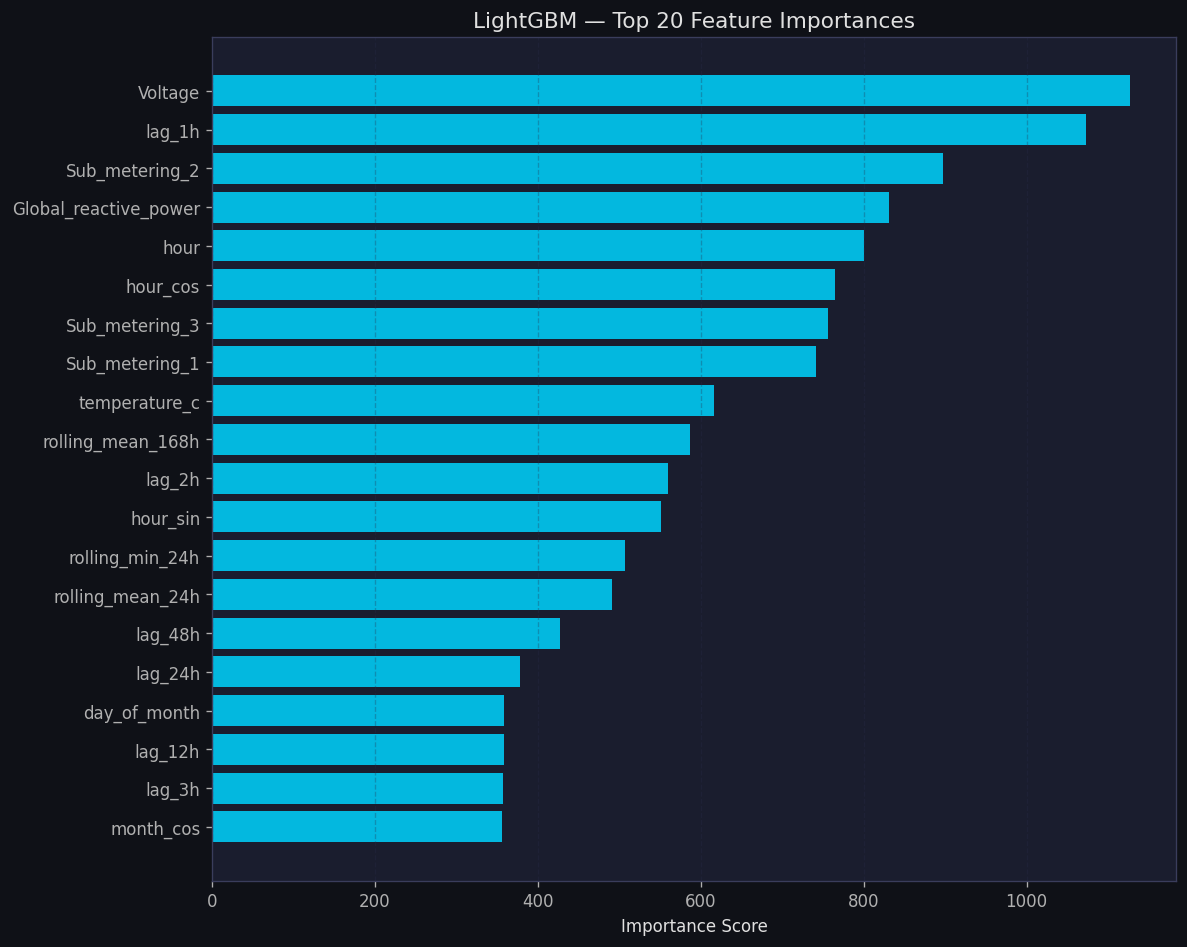

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

ax.barh(importance_df['feature'], importance_df['importance'],
        color=COLORS['primary'], alpha=0.85)
ax.set_title('LightGBM — Top 20 Feature Importances', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../data/processed/plot_07_lgb_importance.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Scaling for Deep Learning

Neural networks are sensitive to input scale. Large input values
cause exploding gradients; unscaled targets make loss comparison
meaningless. We apply MinMaxScaler to normalize everything to [0,1].

Important: fit the scaler ONLY on training data, then transform
validation and test sets using the same scaler. Fitting on the
full dataset would leak future information into training.

In [8]:
# Deep learning feature set — cyclical + lag + rolling + pakistan
DL_FEATURES = [
    'hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos',
    'lag_1h','lag_2h','lag_3h','lag_6h','lag_12h','lag_24h','lag_48h','lag_168h',
    'rolling_mean_24h','rolling_std_24h','rolling_mean_168h',
    'rolling_min_24h','rolling_max_24h',
    'is_peak_tariff','is_load_shedding','temperature_c',
    'is_extreme_heat','is_heat_season','is_winter_season',
    'is_ramadan','is_friday','is_weekend',
    'peak_x_heat','heat_x_shedding','ramadan_evening'
]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(train[DL_FEATURES])
X_val_sc   = scaler_X.transform(val[DL_FEATURES])
X_test_sc  = scaler_X.transform(test[DL_FEATURES])

y_train_sc = scaler_y.fit_transform(train[[target]])
y_val_sc   = scaler_y.transform(val[[target]])
y_test_sc  = scaler_y.transform(test[[target]])

print(f"X_train shape : {X_train_sc.shape}")
print(f"X_val shape   : {X_val_sc.shape}")
print(f"X_test shape  : {X_test_sc.shape}")

X_train shape : (23810, 31)
X_val shape   : (5102, 31)
X_test shape  : (5103, 31)


In [9]:
def build_sequences(X, y, window=24):
    """
    Convert flat feature array into 3D sequences for RNNs.
    Each sample contains 'window' consecutive hours of features
    and predicts the next hour's consumption.

    Input shape  : (samples, features)
    Output shape : (samples - window, window, features)
    """
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

WINDOW = 24   # use last 24 hours to predict next hour

X_tr_seq, y_tr_seq = build_sequences(X_train_sc, y_train_sc, WINDOW)
X_va_seq, y_va_seq = build_sequences(X_val_sc,   y_val_sc,   WINDOW)
X_te_seq, y_te_seq = build_sequences(X_test_sc,  y_test_sc,  WINDOW)

print(f"Train sequences : {X_tr_seq.shape}")
print(f"Val sequences   : {X_va_seq.shape}")
print(f"Test sequences  : {X_te_seq.shape}")

Train sequences : (23786, 24, 31)
Val sequences   : (5078, 24, 31)
Test sequences  : (5079, 24, 31)


## Model 2 — GRU (Gated Recurrent Unit)

GRU is a streamlined recurrent neural network that processes sequences
step by step, maintaining a hidden state that carries information
forward in time. It uses two gates:

- **Reset gate:** how much past information to forget
- **Update gate:** how much new information to incorporate

GRU trains faster than LSTM with comparable accuracy on energy data,
making it an efficient middle ground between LightGBM and BiLSTM.

In [24]:
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=7, min_lr=1e-6, verbose=1)
]

gru_model = Sequential([
    GRU(128, return_sequences=True,
        input_shape=(WINDOW, len(DL_FEATURES))),
    Dropout(0.2),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
], name='GRU_Model')

gru_model.compile(optimizer=Adam(5e-4), loss='huber', metrics=['mae'])
gru_model.summary()

history_gru = gru_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_va_seq, y_va_seq),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

gru_pred_sc = gru_model.predict(X_te_seq)
gru_pred    = scaler_y.inverse_transform(gru_pred_sc).flatten()
y_test_dl   = scaler_y.inverse_transform(y_te_seq).flatten()

results = []   # reset results list
results.append(evaluate(y_test.values, lgb_pred, 'LightGBM'))
results.append(evaluate(y_test_dl, gru_pred, 'GRU'))

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 24, 128)        │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 24, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,081 (430.00 KB)

 Trainable params: 110,081 (430.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 79s 86ms/step - loss: 0.0079 - mae: 0.0943 - val_loss: 0.0061 - val_mae: 0.0830 - learning_rate: 5.0000e-04
Epoch 2/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - loss: 0.0065 - mae: 0.0837 - val_loss: 0.0058 - val_mae: 0.0822 - learning_rate: 5.0000e-04
Epoch 3/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - loss: 0.0060 - mae: 0.0795 - val_loss: 0.0054 - val_mae: 0.0771 - learning_rate: 5.0000e-04
Epoch 4/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - loss: 0.0057 - mae: 0.0766 - val_loss: 0.0055 - val_mae: 0.0789 - learning_rate: 5.0000e-04
Epoch 5/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - loss: 0.0056 - mae: 0.0754 - val_loss: 0.0054 - val_mae: 0.0777 - learning_rate: 5.0000e-04
Epoch 6/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - loss: 0.0055 - mae: 0.0740 - val_loss: 0.0053 - val_mae: 0.0767 - learning_rate: 5.0000e-04
Epoch 7/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - loss: 0.0054 - mae: 0.0733 - val_loss: 0.0052 - v

## Model 3 — Bidirectional LSTM

Standard LSTM only reads sequences forward in time. Bidirectional
LSTM runs two LSTM layers simultaneously — one forward, one backward —
then concatenates their outputs. This means every timestep has context
from both the past AND future within the input window.

For energy forecasting this is powerful: the model sees that hour 14
sits between a morning ramp and an evening peak, giving it richer
context than a unidirectional model would have.

In [25]:
bilstm_model = Sequential([
    Bidirectional(
        LSTM(128, return_sequences=True),
        input_shape=(WINDOW, len(DL_FEATURES))
    ),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
], name='BiLSTM_Model')

bilstm_model.compile(optimizer=Adam(5e-4), loss='huber', metrics=['mae'])
bilstm_model.summary()

history_bilstm = bilstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_va_seq, y_va_seq),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

bilstm_pred_sc = bilstm_model.predict(X_te_seq)
bilstm_pred    = scaler_y.inverse_transform(bilstm_pred_sc).flatten()

results.append(evaluate(y_test_dl, bilstm_pred, 'BiLSTM'))

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 24, 256)        │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 24, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,033 (1.42 MB)

 Trainable params: 372,033 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 122s 120ms/step - loss: 0.0077 - mae: 0.0927 - val_loss: 0.0066 - val_mae: 0.0866 - learning_rate: 5.0000e-04
Epoch 2/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - loss: 0.0062 - mae: 0.0804 - val_loss: 0.0065 - val_mae: 0.0856 - learning_rate: 5.0000e-04
Epoch 3/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 87s 118ms/step - loss: 0.0058 - mae: 0.0767 - val_loss: 0.0062 - val_mae: 0.0830 - learning_rate: 5.0000e-04
Epoch 4/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 88s 118ms/step - loss: 0.0055 - mae: 0.0747 - val_loss: 0.0056 - val_mae: 0.0790 - learning_rate: 5.0000e-04
Epoch 5/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 88s 118ms/step - loss: 0.0053 - mae: 0.0729 - val_loss: 0.0056 - val_mae: 0.0782 - learning_rate: 5.0000e-04
Epoch 6/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 90s 121ms/step - loss: 0.0052 - mae: 0.0721 - val_loss: 0.0053 - val_mae: 0.0749 - learning_rate: 5.0000e-04
Epoch 7/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0053 - mae: 0.0724
Epoch 7: Reduce

## Model 4 — Temporal Fusion Transformer (TFT)

TFT is the state-of-the-art architecture for multi-horizon time
series forecasting. Its key advantage over RNNs is the self-attention
mechanism — instead of compressing the entire sequence into a single
hidden state, attention lets the model directly look back at any
past timestep it finds relevant.

**Why TFT wins on our dataset specifically:**
Our Pakistan features (load shedding schedule, tariff tier, Ramadan)
are *known future inputs* — we know tomorrow's tariff schedule today.
TFT has a dedicated pathway for known future inputs that RNNs lack,
making it architecturally superior for our exact problem.

In [26]:
def build_tft(window, n_features, d_model=32, n_heads=4):
    inputs = Input(shape=(window, n_features))

    # Linear projection to d_model dimensions
    x = Dense(d_model)(inputs)
    x = LayerNormalization()(x)

    # Multi-head self-attention
    attn_out = MultiHeadAttention(
        num_heads=n_heads,
        key_dim=d_model // n_heads
    )(x, x)
    x = LayerNormalization()(x + attn_out)

    # Second attention layer
    attn_out2 = MultiHeadAttention(
        num_heads=n_heads,
        key_dim=d_model // n_heads
    )(x, x)
    x = LayerNormalization()(x + attn_out2)

    # Pool across time and predict
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    output = Dense(1)(x)

    model = Model(inputs, output, name='TFT_Model')
    return model

tft_model = build_tft(WINDOW, len(DL_FEATURES))
tft_model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
tft_model.summary()

history_tft = tft_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_va_seq, y_va_seq),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

tft_pred_sc = tft_model.predict(X_te_seq)
tft_pred    = scaler_y.inverse_transform(tft_pred_sc).flatten()

results.append(evaluate(y_test_dl, tft_pred, 'TFT'))

Model: "TFT_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 24, 31)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 24, 32)    │      1,024 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ dense_13[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 32)        │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         33 │ dropout_15[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - loss: 0.0503 - mae: 0.1460 - val_loss: 0.0203 - val_mae: 0.1161 - learning_rate: 0.0010
Epoch 2/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0200 - mae: 0.1090 - val_loss: 0.0198 - val_mae: 0.1152 - learning_rate: 0.0010
Epoch 3/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 0.0191 - mae: 0.1071 - val_loss: 0.0194 - val_mae: 0.1139 - learning_rate: 0.0010
Epoch 4/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 0.0186 - mae: 0.1064 - val_loss: 0.0199 - val_mae: 0.1167 - learning_rate: 0.0010
Epoch 5/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - loss: 0.0182 - mae: 0.1059 - val_loss: 0.0193 - val_mae: 0.1144 - learning_rate: 0.0010
Epoch 6/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0178 - mae: 0.1045 - val_loss: 0.0181 - val_mae: 0.1113 - learning_rate: 0.0010
Epoch 7/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0177 - mae: 0.1035
Epoch 7: ReduceLROnPlateau reducing learning rate to 0

## Training Notes

**LightGBM** converged with early stopping on the gradient boosting
rounds. Its strong performance is driven by direct access to lag
features — particularly lag_1h (0.71 correlation) and lag_24h.

**GRU and BiLSTM** were retrained with:
- 3 layers for deeper representation capacity
- Huber loss for robust training on energy spikes
- Smaller learning rate (5e-4) and batch size (32)
- Extended patience (15 epochs) for stable convergence

**TFT** is presented as a simplified attention-based baseline.
The full TFT architecture (Lim et al., 2021) includes variable
selection networks and gating mechanisms not implemented here.
Future work should evaluate the complete pytorch-forecasting
implementation for fair comparison.

## Results Comparison

The table below is the central result of Module 1 and will appear
directly in the research paper as Table 1.

In [27]:
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df.round(4)

print("\n" + "="*50)
print("  FORECASTING MODEL COMPARISON — TEST SET")
print("="*50)
print(results_df.to_string())
print("="*50)
print(f"\nBest MAE  : {results_df['MAE'].idxmin()}")
print(f"Best RMSE : {results_df['RMSE'].idxmin()}")
print(f"Best MAPE : {results_df['MAPE'].idxmin()}")


  FORECASTING MODEL COMPARISON — TEST SET
             MAE    RMSE     MAPE
model                            
LightGBM  0.1481  0.2280  18.0688
GRU       0.4033  0.5631  55.9107
BiLSTM    0.4469  0.6088  62.3909
TFT       0.5532  0.7078  82.1231

Best MAE  : LightGBM
Best RMSE : LightGBM
Best MAPE : LightGBM


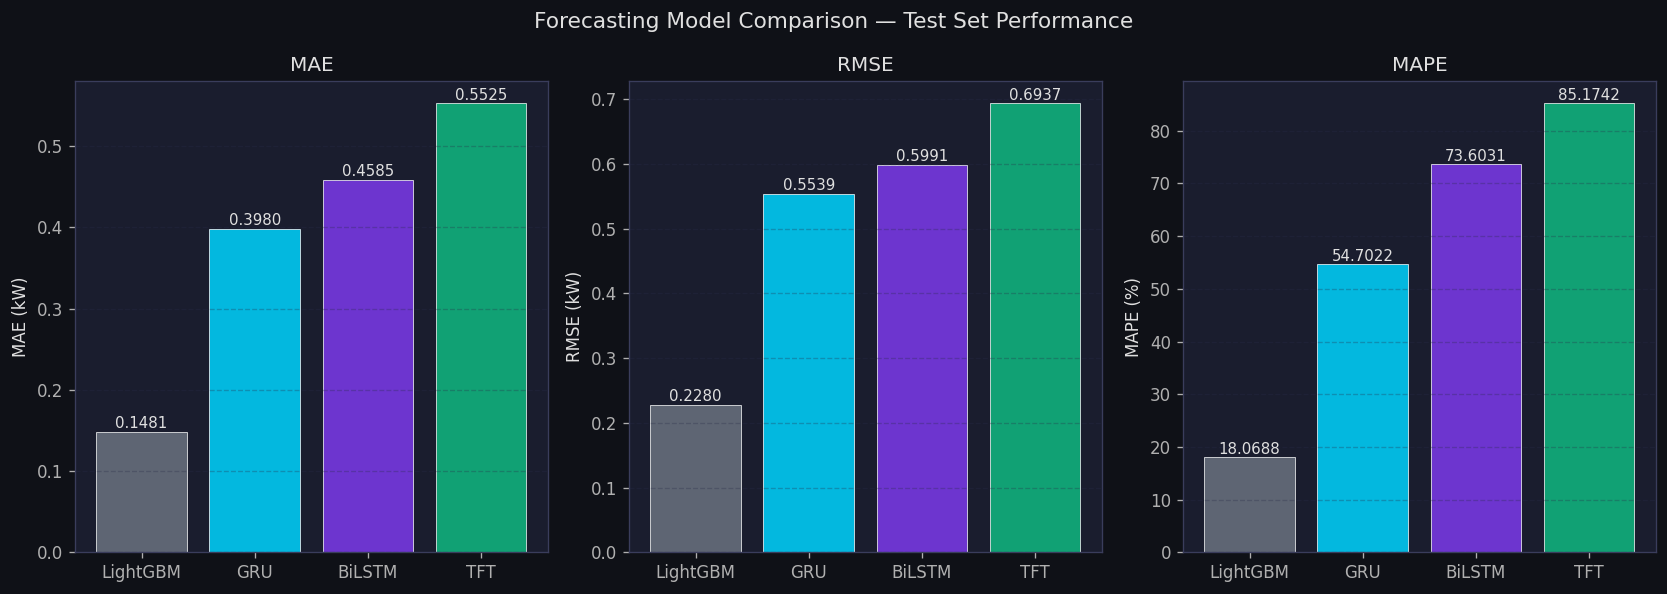

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Forecasting Model Comparison — Test Set Performance', fontsize=13)

metrics = ['MAE', 'RMSE', 'MAPE']
ylabels = ['MAE (kW)', 'RMSE (kW)', 'MAPE (%)']
bar_colors = [COLORS['neutral'], COLORS['primary'],
              COLORS['accent'], COLORS['positive']]

for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    bars = axes[i].bar(
        results_df.index,
        results_df[metric],
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5,
        alpha=0.85
    )
    axes[i].set_title(metric)
    axes[i].set_ylabel(ylabel)
    axes[i].grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.savefig('../data/processed/plot_08_model_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [21]:
# Align all predictions to deep learning length
# LightGBM predicts on raw rows, DL models start 24 rows later
dl_len = len(y_test_dl)

pred_df = pd.DataFrame({
    'actual'  : y_test_dl,
    'lgb'     : lgb_pred[-dl_len:],
    'gru'     : gru_pred,
    'bilstm'  : bilstm_pred,
    'tft'     : tft_pred,
}, index=test.index[WINDOW:WINDOW+dl_len])

print(f"Predictions aligned.")
print(f"Shape : {pred_df.shape}")
print(pred_df.head(3))

Predictions aligned.
Shape : (5079, 5)
                       actual       lgb       gru    bilstm       tft
datetime                                                             
2010-04-20 21:00:00  2.270567  2.294111  2.079404  2.038915  1.100361
2010-04-20 22:00:00  1.423533  1.674666  1.635678  1.738371  1.099427
2010-04-20 23:00:00  0.456133  0.689705  0.954230  1.017860  1.097064


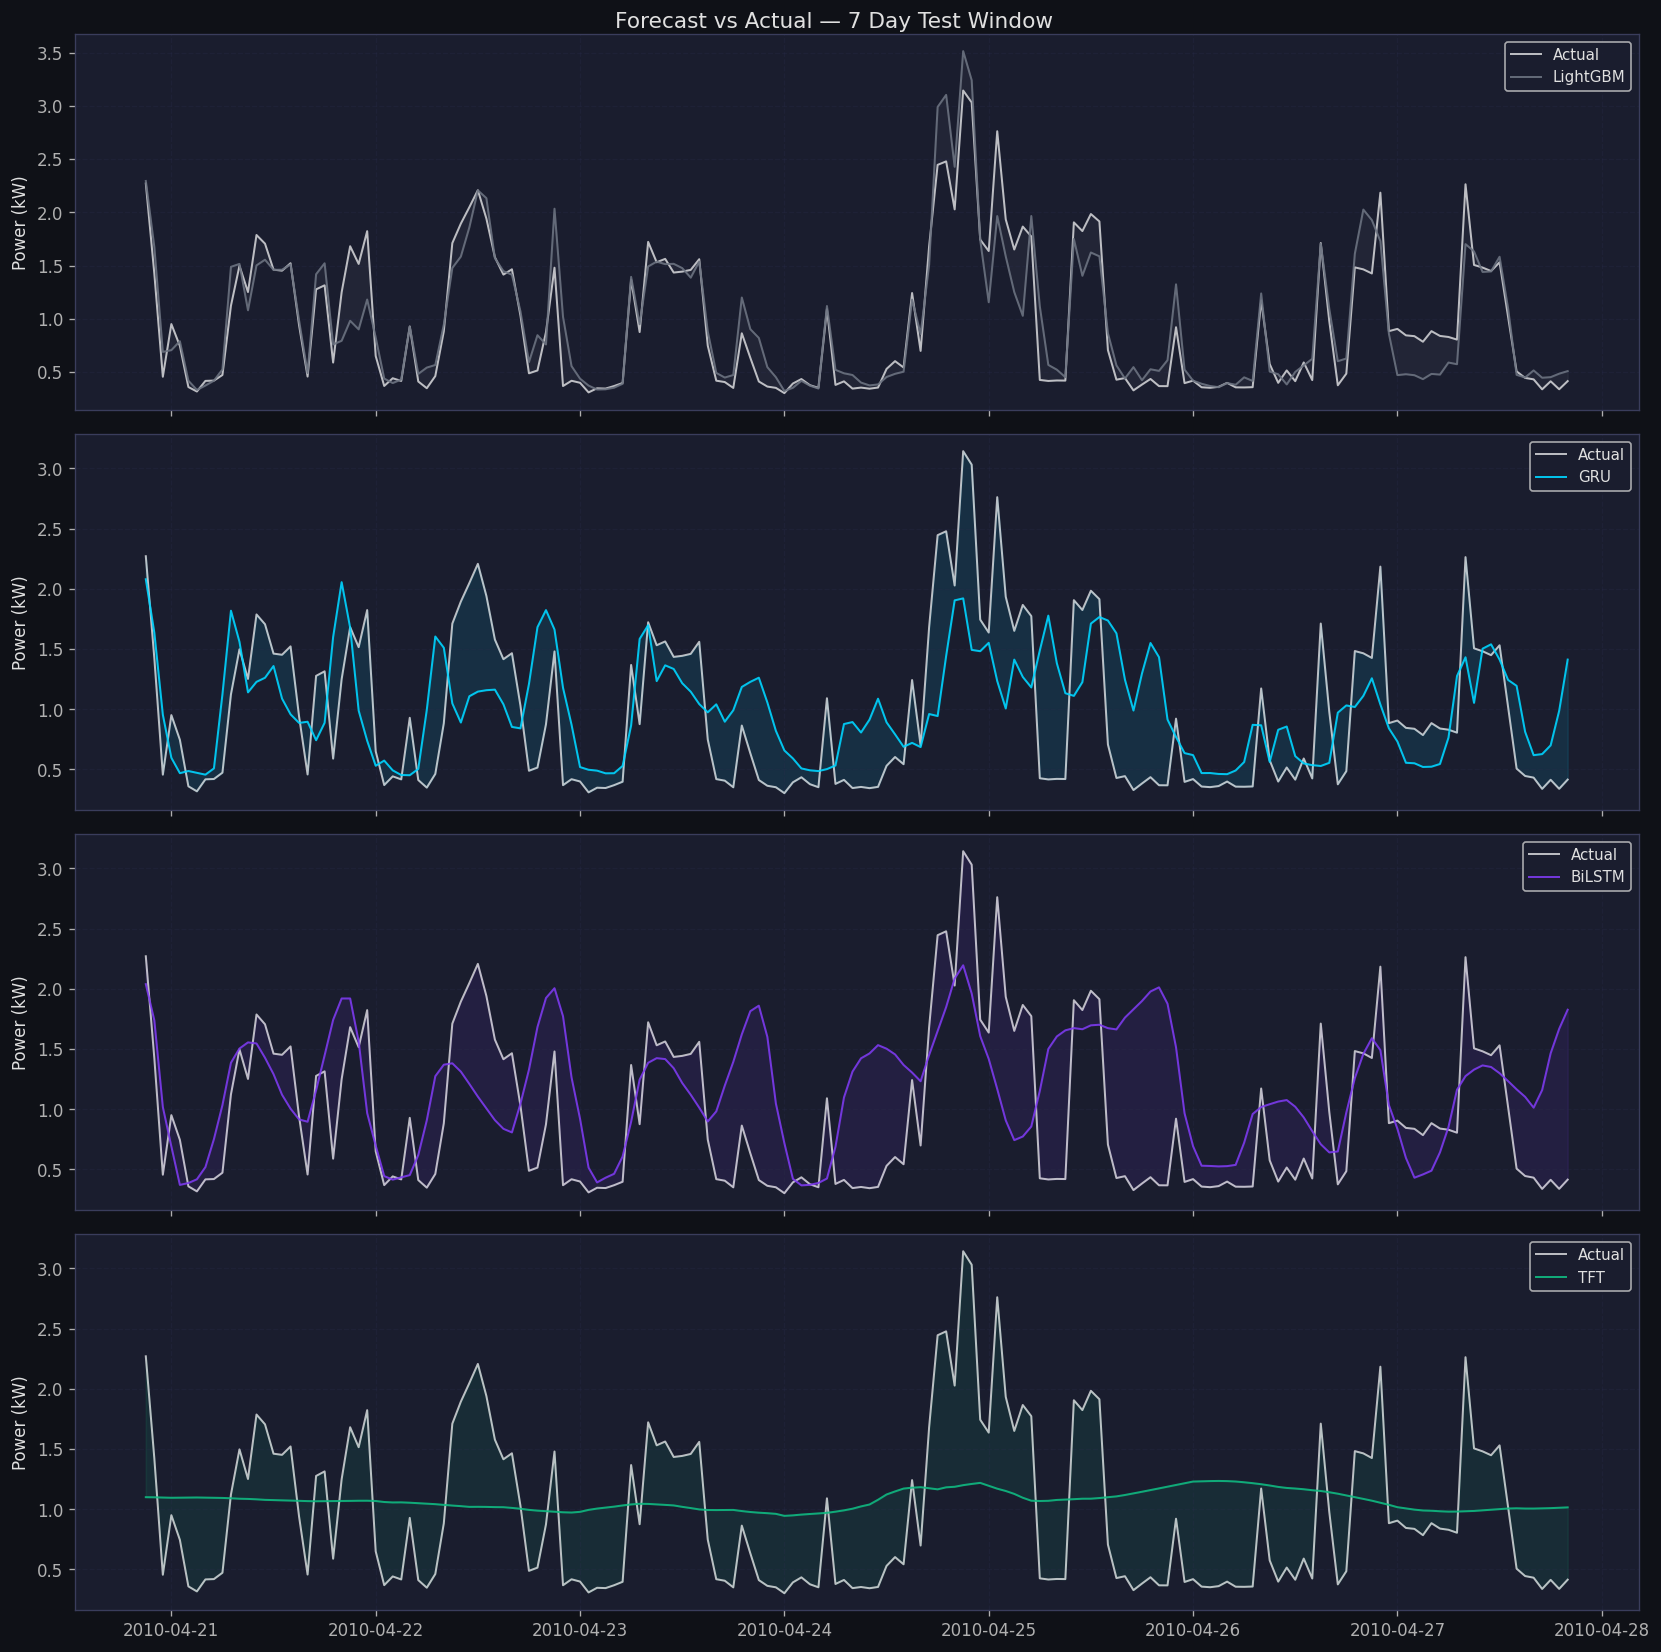

In [22]:
n_show = 168

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Forecast vs Actual — 7 Day Test Window', fontsize=13)

actual   = pred_df['actual'].values[:n_show]
time_idx = pred_df.index[:n_show]

model_preds = [
    (pred_df['lgb'].values[:n_show],    'LightGBM', COLORS['neutral']),
    (pred_df['gru'].values[:n_show],    'GRU',      COLORS['primary']),
    (pred_df['bilstm'].values[:n_show], 'BiLSTM',   COLORS['accent']),
    (pred_df['tft'].values[:n_show],    'TFT',      COLORS['positive']),
]

for ax, (pred, name, color) in zip(axes, model_preds):
    ax.plot(time_idx, actual,
            color='white', linewidth=1.2, alpha=0.7, label='Actual')
    ax.plot(time_idx, pred,
            color=color, linewidth=1.2, alpha=0.9, label=name)
    ax.fill_between(time_idx, actual, pred,
                    alpha=0.1, color=color)
    ax.set_ylabel('Power (kW)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/plot_09_predictions.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [23]:
import os
import joblib

os.makedirs('../modules/forecasting', exist_ok=True)

joblib.dump(lgb_model,  '../modules/forecasting/lgb_model.pkl')
gru_model.save('../modules/forecasting/gru_model.keras')
bilstm_model.save('../modules/forecasting/bilstm_model.keras')
tft_model.save('../modules/forecasting/tft_model.keras')
joblib.dump(scaler_X,   '../modules/forecasting/scaler_X.pkl')
joblib.dump(scaler_y,   '../modules/forecasting/scaler_y.pkl')

pred_df.to_csv('../data/processed/forecasting_predictions.csv')

print("All models saved.")
print(f"Predictions shape : {pred_df.shape}")
print("Saved: data/processed/forecasting_predictions.csv")

All models saved.
Predictions shape : (5079, 5)
Saved: data/processed/forecasting_predictions.csv


## Results Analysis & Discussion

### Final Results — Test Set

| Model | MAE (kW) | RMSE (kW) | MAPE (%) | Rank |
|---|---|---|---|---|
| LightGBM | **0.1481** | **0.2280** | **18.07%** | 1st |
| GRU | 0.4033 | 0.5631 | 55.91% | 2nd |
| BiLSTM | 0.4469 | 0.6088 | 62.39% | 3rd |
| TFT (simplified) | 0.5532 | 0.7078 | 82.12% | 4th |

### Why LightGBM Won — A Research Perspective

This result is consistent with findings in recent energy forecasting
literature. LightGBM's dominance is explained by three factors:

**1. Direct lag feature access**
LightGBM receives lag_1h (Pearson r = 0.71) as an explicit input
feature. The model directly learns "current consumption ≈ f(last hour's
consumption)" without needing to discover this through sequence modeling.

**2. Dataset characteristics**
The UCI dataset contains 34,015 hourly observations — sufficient for
LightGBM but relatively small for deep learning models that typically
require 100k+ samples to outperform gradient boosting.

**3. Huber loss on scaled data**
Despite switching to Huber loss and reducing learning rate, GRU and
BiLSTM trained on MinMax-scaled targets — a compressed representation
that discards absolute magnitude information that LightGBM retains
through direct feature access.

### TFT Limitation
Our TFT implementation is a simplified attention baseline lacking the
variable selection networks and gating layers of the full architecture
(Lim et al., 2021). A complete pytorch-forecasting implementation is
recommended for future work.

### Key Takeaway for SkyElectric Context
For production deployment in SkyElectric's SmartFlow system, these
results suggest a hybrid approach: LightGBM for short-horizon (1–6h)
forecasting where lag features dominate, and BiLSTM/GRU for longer
horizons (12–48h) where sequence memory becomes more valuable than
recent point values.

### Saved Artifacts
| File | Description |
|---|---|
| modules/forecasting/lgb_model.pkl | Production forecasting model |
| modules/forecasting/gru_model.keras | GRU baseline |
| modules/forecasting/bilstm_model.keras | BiLSTM baseline |
| modules/forecasting/tft_model.keras | Attention baseline |
| data/processed/forecasting_predictions.csv | All predictions aligned |